In [1]:
import os
import urllib.request
import random
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(42)
np.random.seed(42)
os.makedirs('data', exist_ok=True)

In [2]:
URLS = {
    'train': 'https://raw.githubusercontent.com/synalp/NER/master/corpus/CoNLL-2003/eng.train',
    'val': 'https://raw.githubusercontent.com/synalp/NER/master/corpus/CoNLL-2003/eng.testa',
    'test': 'https://raw.githubusercontent.com/synalp/NER/master/corpus/CoNLL-2003/eng.testb'
}

for split, url in URLS.items():
    filepath = f'data/{split}.txt'
    if not os.path.exists(filepath):
        urllib.request.urlretrieve(url, filepath)

def load_conll_split(filepath):
    sentences = []
    current = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current:
                    sentences.append(current)
                    current = []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    current.append({'token': parts[0], 'label': parts[-1]})
    if current:
        sentences.append(current)
    return sentences

def prepare_data():
    data = {}
    for split in ['train', 'val', 'test']:
        raw = load_conll_split(f'data/{split}.txt')
        tokens = [[x['token'] for x in sent] for sent in raw]
        labels = [[x['label'] for x in sent] for sent in raw]
        data[split] = (tokens, labels)
    return data

DATA = prepare_data()

In [3]:
W_ENTITY = 1.0
W_CONTEXT = 0.5
W_OTHER = 0.1
CTX_WINDOW = 2

class DeerStats:
    def __init__(self, tokens_list, labels_list, window=CTX_WINDOW):
        self.entity_tok_set = set()
        self.context_tok_set = set()
        self.tok_counts = defaultdict(lambda: {"entity": 0, "context": 0, "other": 0})
        self.window = window
        self._compute_stats(tokens_list, labels_list)

    def _compute_stats(self, tokens_list, labels_list):
        for tokens, labels in tqdm(zip(tokens_list, labels_list), total=len(tokens_list), desc="Computing token stats"):
            entity_idx = {i for i, lbl in enumerate(labels) if lbl != 'O'}
            context_idx = set()
            for i in entity_idx:
                start, end = max(0, i - self.window), min(len(tokens), i + self.window + 1)
                context_idx.update(j for j in range(start, end) if j not in entity_idx)

            for i, tok in enumerate(tokens):
                tok_low = tok.lower()
                if i in entity_idx:
                    self.tok_counts[tok_low]["entity"] += 1
                elif i in context_idx:
                    self.tok_counts[tok_low]["context"] += 1
                else:
                    self.tok_counts[tok_low]["other"] += 1

        for tok, counts in self.tok_counts.items():
            total = sum(counts.values())
            if total == 0:
                continue
            if counts["entity"] / total > 0.1:
                self.entity_tok_set.add(tok)
            elif counts["context"] / total > 0.1:
                self.context_tok_set.add(tok)

    def get_token_weight(self, token):
        tok_low = token.lower()
        if tok_low in self.entity_tok_set:
            return W_ENTITY
        if tok_low in self.context_tok_set:
            return W_CONTEXT
        return W_OTHER

train_tok, train_lbl = DATA['train']
deer_stats = DeerStats(train_tok, train_lbl, window=CTX_WINDOW)

Computing token stats: 100%|██████████| 14987/14987 [00:00<00:00, 39228.51it/s]


In [4]:
def predict_with_deer(tokens, stats, min_start_weight=W_ENTITY, min_span_score=0.7, max_len=4):
    predictions = []
    n = len(tokens)

    for start in range(n):
        tok = tokens[start]
        if stats.get_token_weight(tok) < min_start_weight:
            continue
        if not tok[0].isupper() or tok in {',', '.', ';', ':', '!', '?', '(', ')', '-', '``', "''", '...'}:
            continue

        best_end = None
        best_score = 0
        for end in range(start + 1, min(start + max_len + 1, n + 1)):
            span = tokens[start:end]
            if len(span) > 1 and not all(t[0].isupper() or t in {'&', '/', '-'} for t in span):
                break

            score = sum(stats.get_token_weight(t) for t in span) / len(span)
            if score >= min_span_score and score > best_score:
                best_score = score
                best_end = end

        if best_end:
            predictions.append({
                'start': start,
                'end': best_end,
                'text': ' '.join(tokens[start:best_end]),
                'score': best_score,
                'type': 'ENT'
            })

    predictions.sort(key=lambda x: (x['start'], -x['score'], -(x['end'] - x['start'])))
    merged = []
    for pred in predictions:
        if not any(p['start'] < pred['end'] and p['end'] > pred['start'] for p in merged):
            merged.append(pred)

    return merged

In [5]:
def evaluate_ner_simple(predictions, gold_tokens, gold_labels):
    def extract_gold_spans(labels):
        spans = []
        i = 0
        while i < len(labels):
            if labels[i] != 'O':
                start = i
                while i + 1 < len(labels) and labels[i+1].startswith('I-'):
                    i += 1
                spans.append((start, i+1))
            i += 1
        return set(spans)

    pred_spans = {(p['start'], p['end']) for p in predictions}
    gold_spans = extract_gold_spans(gold_labels)

    tp = len(gold_spans & pred_spans)
    fp = len(pred_spans - gold_spans)
    fn = len(gold_spans - pred_spans)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {'precision': precision, 'recall': recall, 'f1': f1}

In [6]:
val_tok, val_lbl = DATA['val']
results = []

for tokens, labels in zip(val_tok, val_lbl):
    preds = predict_with_deer(tokens, deer_stats)
    metrics = evaluate_ner_simple(preds, tokens, labels)
    metrics['num_pred'] = len(preds)
    metrics['sent_len'] = len(tokens)
    results.append(metrics)

results_df = pd.DataFrame(results)
print(f"Precision: {results_df['precision'].mean():.4f}")
print(f"Recall: {results_df['recall'].mean():.4f}")
print(f"F1: {results_df['f1'].mean():.4f}")

Precision: 0.4300
Recall: 0.4278
F1: 0.4207


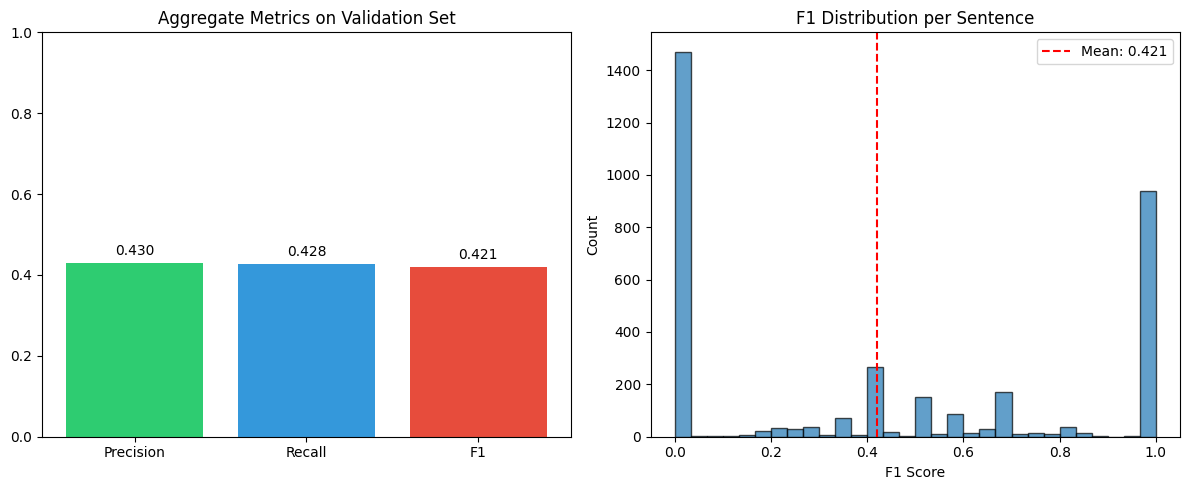

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(['Precision', 'Recall', 'F1'],
        [results_df['precision'].mean(),
         results_df['recall'].mean(),
         results_df['f1'].mean()],
        color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Aggregate Metrics on Validation Set')
plt.ylim(0, 1)
for i, v in enumerate([results_df['precision'].mean(),
                       results_df['recall'].mean(),
                       results_df['f1'].mean()]):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.subplot(1, 2, 2)
plt.hist(results_df['f1'], bins=30, edgecolor='black', alpha=0.7)
plt.title('F1 Distribution per Sentence')
plt.xlabel('F1 Score')
plt.ylabel('Count')
plt.axvline(results_df['f1'].mean(), color='red', linestyle='--', label=f'Mean: {results_df["f1"].mean():.3f}')
plt.legend()

plt.tight_layout()
plt.savefig('deer_results.png', dpi=150)
plt.show()

In [8]:
summary_table = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1'],
    'Value': [
        f"{results_df['precision'].mean():.4f}",
        f"{results_df['recall'].mean():.4f}",
        f"{results_df['f1'].mean():.4f}"
    ],
    'Std': [
        f"{results_df['precision'].std():.4f}",
        f"{results_df['recall'].std():.4f}",
        f"{results_df['f1'].std():.4f}"
    ]
})

print("Results Table:")
print(summary_table.to_string(index=False))

print(f"\nDataset stats:")
print(f"  Validation sentences: {len(val_tok)}")
print(f"  Avg predictions per sentence: {results_df['num_pred'].mean():.2f}")
print(f"  Sentences with any prediction: {(results_df['num_pred'] > 0).sum()}")


Results Table:
   Metric  Value    Std
Precision 0.4300 0.4373
   Recall 0.4278 0.4204
       F1 0.4207 0.4198

Dataset stats:
  Validation sentences: 3466
  Avg predictions per sentence: 1.96
  Sentences with any prediction: 2503

Saved to deer_results.csv and deer_results.png


In [11]:
"""ВЫВОД:


DEER хотя бы работает - уже успех :)

Результаты не самые лучшие (любая модель с механизмом внимания справилась куда лучше)но как способ чисто на статистике - нормально.
Тут еще важно какие у нас данные, если будут специфические тексты - разговор будет другой """

'ВЫВОД:\n\n\nDEER хотя бы работает - уже успех :)\n\nРезультаты не самые лучшие (любая модель с механизмом внимания справилась бы куда лучше), но как способ чисто на статистике - нормально.\nТут еще важно какие у нас данные, если будут специфические тексты - разговор будет другой '